## Importing File

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

zip_file_path = '/content/drive/MyDrive/Sentiment_Data.zip'
extract_to_folder = './Sentiment_Data'

# Create folder
os.makedirs(extract_to_folder, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_folder)

print(f"Zip file extracted to: {extract_to_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zip file extracted to: ./Sentiment_Data


In [3]:
import pandas as pd

In [4]:
csv_path = 'Sentiment_Data/Sentiment_Data.csv'

In [5]:
df = pd.read_csv(csv_path, encoding='latin1')

In [6]:
print(df.head())  # Shows the first 5 rows

                                               Tweet Sentiment
0  @_angelica_toy Happy Anniversary!!!....The Day...  Mild_Pos
1  @McfarlaneGlenda Happy Anniversary!!!....The D...  Mild_Pos
2  @thevivafrei @JustinTrudeau Happy Anniversary!...  Mild_Pos
3  @NChartierET Happy Anniversary!!!....The Day t...  Mild_Pos
4  @tabithapeters05 Happy Anniversary!!!....The D...  Mild_Pos


## Info about the data

In [7]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB
None
         Tweet   Sentiment
count   451331      451332
unique  451279           5
top     #NAME?  Strong_Pos
freq         5      233700


## Check for missing values:

In [8]:
print(df.isnull().sum())

Tweet        1
Sentiment    0
dtype: int64


## View sample tweets with their sentiment

In [9]:
for i in range(5):
    print(f"Tweet: {df.iloc[i, 0]}")
    print(f"Sentiment: {df.iloc[i, 1]}")
    print("-" * 40)

Tweet: @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9
Sentiment: Mild_Pos
----------------------------------------
Tweet: @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9
Sentiment: Mild_Pos
----------------------------------------
Tweet: @thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9
Sentiment: Mild_Pos
----------------------------------------
Tweet: @NChartierET Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedum

## Cleaning the Data

### Regex Cleaning
Removing mentions URLs, hashtags, punctuation, and converting text to lowercase

In [10]:
import re

def clean_tweet(text):
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)     # Remove mentions
    text = re.sub(r'#\w+', '', text)     # Remove hashtags
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower().strip()           # Lowercase and trim spaces
    return text

df['Clean_Tweet'] = df['Tweet'].astype(str).apply(clean_tweet)

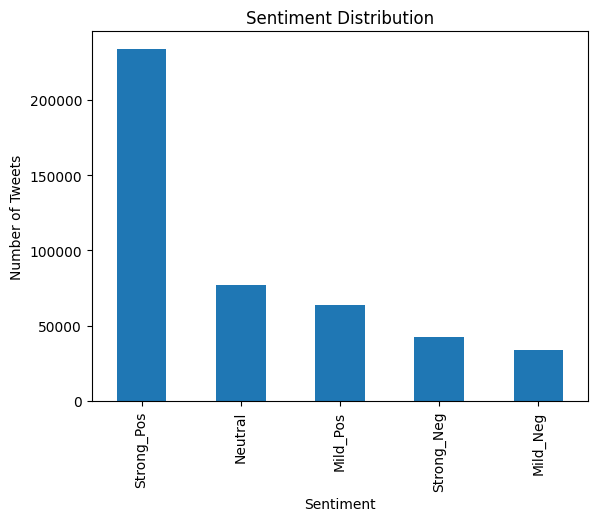

In [11]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

## Display original vs cleaned tweets for first 10 rows

In [12]:
for i in range(10):
    print(f"Original Tweet {i+1}: {df.loc[i, 'Tweet']}")
    print(f"Cleaned Tweet  {i+1}: {df.loc[i, 'Clean_Tweet']}")
    print('-' * 100)

Original Tweet 1: @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9
Cleaned Tweet  1: happy anniversarythe day the freedumb died in the tune of don mcleans american pie
----------------------------------------------------------------------------------------------------
Original Tweet 2: @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9
Cleaned Tweet  2: happy anniversarythe day the freedumb died in the tune of don mcleans american pie
----------------------------------------------------------------------------------------------------
Original Tweet 3: @thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "Amer

### Map sentiment labels to three classes to simplyfy

In [13]:
def map_sentiment(sent):
    if 'Pos' in sent:
        return 'Positive'
    elif 'Neg' in sent:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment_3class'] = df['Sentiment'].apply(map_sentiment)

## Handling missing data

In [14]:
df = df.dropna(subset=['Clean_Tweet'])

## Removing Duplicates

In [15]:
df = df.drop_duplicates(subset=['Clean_Tweet'])

## Encode Lables

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# DF is DataFrame and 'Sentiment_3class' is  categorical column
df['Sentiment_Label'] = le.fit_transform(df['Sentiment_3class'])

#Check the mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding mapping:", label_mapping)

Label encoding mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


## Hence handled REGEX already we are displaying the sample results

In [17]:
print("Sample cleaned tweets with sentiment:")
print(df[['Clean_Tweet', 'Sentiment_3class']].sample(10))

Sample cleaned tweets with sentiment:
                                              Clean_Tweet Sentiment_3class
385698  ottawa police may call in military as âfreedom...          Neutral
275705  trudeau has invoked the emergencies act in res...         Positive
329749  marazzo the socalled leader of the freedom con...         Positive
48501   tonight moving on from the   commission testim...          Neutral
153564  again intimidation and abuse against these pea...          Neutral
321478  freedom convoy protesters who block streets co...         Negative
427676  serve the truckers or face the losses  \nwe do...         Negative
73030   what about the thousands of missed appointment...         Positive
154729  another freedom convoy rolls through ottawa as...         Positive
79839   jan 29 convoy with all freedom in the world se...         Positive


## Handling Emojis

In [18]:
import re

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002500-\U00002BEF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001f926-\U0001f937"
        "\U00010000-\U0010ffff"
        "\u2640-\u2642"
        "\u2600-\u2B55"
        "\u200d"
        "\u23cf"
        "\u23e9"
        "\u231a"
        "\ufe0f"  # dingbats
        "\u3030"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

# Apply emoji removal to 'Clean_Tweet' column
df['Clean_Tweet_No_Emoji'] = df['Clean_Tweet'].apply(remove_emojis)

# Check results
print(df[['Clean_Tweet', 'Clean_Tweet_No_Emoji']].head())

                                          Clean_Tweet  \
0   happy anniversarythe day the freedumb died in ...   
8                      freedom convoy as inkblot test   
13  well itâs pretty easy to see what their agenda...   
23                                 you belong in jail   
25                                                      

                                 Clean_Tweet_No_Emoji  
0   happy anniversarythe day the freedumb died in ...  
8                      freedom convoy as inkblot test  
13  well itâs pretty easy to see what their agenda...  
23                                 you belong in jail  
25                                                     


## Slang Handling

In [19]:
slang_dict = {
    "aight": "alright",
    "afaik": "as far as i know",
    "afk": "away from keyboard",
    "asl": "age sex location",
    "atm": "at the moment",
    "b4": "before",
    "bday": "birthday",
    "bff": "best friend forever",
    "brb": "be right back",
    "btw": "by the way",
    "cya": "see you",
    "dm": "direct message",
    "fomo": "fear of missing out",
    "ftw": "for the win",
    "ftl": "for the loss",
    "fyi": "for your information",
    "gg": "good game",
    "gr8": "great",
    "gtg": "got to go",
    "idc": "i do not care",
    "idk": "i do not know",
    "ikr": "i know right",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "k": "okay",
    "lmao": "laughing my ass off",
    "lmfao": "laughing my freaking ass off",
    "lol": "laughing out loud",
    "nvm": "never mind",
    "omg": "oh my god",
    "plz": "please",
    "ppl": "people",
    "rofl": "rolling on the floor laughing",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "tgif": "thank god it’s friday",
    "thx": "thanks",
    "ttyl": "talk to you later",
    "wtf": "what the heck",
    "yolo": "you only live once",
    "yw": "you’re welcome",
    "u": "you",
    "ur": "your",
    "r": "are",
    "y": "why",
    "w/": "with",
    "w/o": "without",
    "b/c": "because",
    "bc": "because",
    "pls": "please",
    "tho": "though",
    "cus": "because",
    "cuz": "because",
    "def": "definitely",
    "esp": "especially",
    "ex": "example",
    "fb": "facebook",
    "fam": "family",
    "fave": "favorite",
    "ft": "feet",
    "gg": "good game",
    "grats": "congratulations",
    "guys": "people",
    "hbu": "how about you",
    "hf": "have fun",
    "ikr": "i know right",
    "ily": "i love you",
    "ilysm": "i love you so much",
    "imo": "in my opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "k": "okay",
    "kk": "okay",
    "lmk": "let me know",
    "lol": "laughing out loud",
    "n/a": "not applicable",
    "nm": "not much",
    "np": "no problem",
    "nsfw": "not safe for work",
    "omw": "on my way",
    "otp": "on the phone",
    "pov": "point of view",
    "ppl": "people",
    "qotd": "quote of the day",
    "rn": "right now",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "tbt": "throwback thursday",
    "tfw": "that feeling when",
    "tho": "though",
    "tmi": "too much information",
    "ttyl": "talk to you later",
    "ty": "thank you",
    "tyvm": "thank you very much",
    "wbu": "what about you",
    "wyd": "what are you doing",
    "yw": "you’re welcome",
    "zzz": "sleeping",
    "af": "as f***",
    "bump": "bring up my post",
    "cake": "someone's birthday",
    "clapback": "response to criticism",
    "dead": "very amused",
    "flex": "show off",
    "ghost": "to ignore",
    "goat": "greatest of all time",
    "sus": "suspicious",
    "tea": "gossip",
    "vibe": "feeling or atmosphere",
    "woke": "socially aware",
    "yeet": "throw forcefully"
}

In [20]:
# Function to replace slang words in text
def replace_slang(text):
    # Tokenize the text by whitespace
    words = text.split()
    new_words = []
    for word in words:
        # Lowercase word for matching
        w_lower = word.lower()
        # Replace if slang found, else keep original
        if w_lower in slang_dict:
            new_words.append(slang_dict[w_lower])
        else:
            new_words.append(word)
    return ' '.join(new_words)

# Apply slang replacement to dataframe column
df['Clean_Tweet_Slang_Handled'] = df['Clean_Tweet_No_Emoji'].apply(replace_slang)

# Check result samples
print(df[['Clean_Tweet_No_Emoji', 'Clean_Tweet_Slang_Handled']].head())

                                 Clean_Tweet_No_Emoji  \
0   happy anniversarythe day the freedumb died in ...   
8                      freedom convoy as inkblot test   
13  well itâs pretty easy to see what their agenda...   
23                                 you belong in jail   
25                                                      

                            Clean_Tweet_Slang_Handled  
0   happy anniversarythe day the freedumb died in ...  
8                      freedom convoy as inkblot test  
13  well itâs pretty easy to see what their agenda...  
23                                 you belong in jail  
25                                                     


In [21]:
abbreviation_dict = {
    "asap": "as soon as possible",
    "brb": "be right back",
    "idk": "i do not know",
    "fyi": "for your information",
    "lol": "laughing out loud",
    "omg": "oh my god",
    "tba": "to be announced",
    "tbd": "to be decided",
    "atm": "at the moment",
    "bff": "best friends forever",
    "btw": "by the way",
    "etc": "et cetera",
    "eod": "end of day",
    "faq": "frequently asked questions",
    "fomo": "fear of missing out",
    "gg": "good game",
    "imo": "in my opinion",
    "irl": "in real life",
    "lmk": "let me know",
    "np": "no problem",
    "omw": "on my way",
    "pov": "point of view",
    "rt": "retweet",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "ttyl": "talk to you later",
    "wfh": "work from home",
    "wth": "what the heck",
    "afk": "away from keyboard",
    "atm": "automated teller machine",
    "bday": "birthday",
    "bump": "bring up my post",
    "cya": "see you",
    "dm": "direct message",
    "diy": "do it yourself",
    "ftw": "for the win",
    "fyi": "for your information",
    "gg": "good game",
    "gr8": "great",
    "gtg": "got to go",
    "hbd": "happy birthday",
    "hf": "have fun",
    "icymi": "in case you missed it",
    "jk": "just kidding",
    "k": "okay",
    "lmao": "laughing my ass off",
    "lmfao": "laughing my freaking ass off",
    "msg": "message",
    "nsfw": "not safe for work",
    "nvm": "never mind",
    "ppl": "people",
    "rofl": "rolling on the floor laughing",
    "rt": "retweet",
    "srsly": "seriously",
    "tgif": "thank god it's friday",
    "thx": "thanks",
    "ttys": "talk to you soon",
    "wbu": "what about you",
    "wyd": "what are you doing",
    "yw": "you're welcome",
    "zzz": "sleeping",
    "afaik": "as far as i know",
    "atm": "at the moment",
    "bbl": "be back later",
    "cba": "can't be arsed",
    "cu": "see you",
    "fomo": "fear of missing out",
    "ftl": "for the loss",
    "g2g": "got to go",
    "gl": "good luck",
    "gmta": "great minds think alike",
    "ic": "i see",
    "ilu": "i love you",
    "imo": "in my opinion",
    "irl": "in real life",
    "j/k": "just kidding",
    "l8r": "later",
    "lolz": "laughing out loud",
    "mfw": "my face when",
    "np": "no problem",
    "oic": "oh i see",
    "omfg": "oh my freaking god",
    "pov": "point of view",
    "ppl": "people",
    "roflmao": "rolling on the floor laughing my ass off",
    "rtfm": "read the freaking manual",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "tldr": "too long didn't read",
    "tmi": "too much information",
    "ty": "thank you",
    "w/e": "whatever",
    "w/o": "without",
    "wth": "what the heck",
    "xoxo": "hugs and kisses",
    "yolo": "you only live once",
    "yw": "you're welcome",
    "zzz": "sleeping",
}

In [22]:
def replace_abbreviations(text):
    words = text.split()
    new_words = []
    for word in words:
        w_lower = word.lower()
        if w_lower in abbreviation_dict:
            new_words.append(abbreviation_dict[w_lower])
        else:
            new_words.append(word)
    return ' '.join(new_words)

df['Text_Abbr_Handled'] = df['Clean_Tweet_Slang_Handled'].apply(replace_abbreviations)

In [23]:

def find_abbreviations(text, abbr_dict):
    words = text.lower().split()
    found_abbrs = set()
    for w in words:
        if w in abbr_dict:
            found_abbrs.add(w)
    return list(found_abbrs)

# Apply to your dataframe column
df['abbreviations_found'] = df['Clean_Tweet_Slang_Handled'].apply(lambda x: find_abbreviations(x, abbreviation_dict))

# Show rows with abbreviations found (non-empty list)
print(df[df['abbreviations_found'].map(len) > 0][['Clean_Tweet_Slang_Handled', 'abbreviations_found']])

                                Clean_Tweet_Slang_Handled abbreviations_found
369     ujokeularvein explains why the canadian freedo...                [rt]
614     hmmm so cbc has retracted several stories late...               [etc]
637     may be more specifics into what all areas you ...               [etc]
1018    will you be celebrating the freedom convoy as ...               [etc]
1066    please announce asap canadians are missing the...              [asap]
...                                                   ...                 ...
451303  gaza freedom convoy has met malaysian australi...                [rt]
451304  rt follow because everyone on that convoy righ...                [rt]
451314  rt directions and parking info for fort lauder...                [rt]
451317  rt express arrived in albuquerque to a huge cr...                [rt]
451328  face of defense soldier finds freedom in us fi...                [rt]

[3308 rows x 2 columns]


In [24]:
from collections import Counter

# Flatten all abbreviations found into one list
all_abbrs = [abbr for sublist in df['abbreviations_found'] for abbr in sublist]

# Count frequency of each abbreviation
abbr_counts = Counter(all_abbrs)

# Show top 20 most common abbreviations
print(abbr_counts.most_common(20))

[('etc', 1754), ('rt', 1007), ('icymi', 193), ('asap', 132), ('wth', 58), ('msg', 35), ('cu', 27), ('omfg', 21), ('tldr', 16), ('lolz', 11), ('ic', 11), ('gl', 7), ('tba', 6), ('wfh', 5), ('oic', 5), ('xoxo', 4), ('tbd', 4), ('cba', 3), ('srsly', 3), ('faq', 2)]


In [25]:
top_abbrs = ['etc', 'rt', 'icymi', 'asap', 'wth', 'msg', 'cu', 'omfg', 'tldr', 'lolz']

In [26]:
abbr_expansions = {
    "etc": "et cetera",
    "rt": "retweet",
    "icymi": "in case you missed it",
    "asap": "as soon as possible",
    "wth": "what the heck",
    "msg": "message",
    "cu": "see you",
    "omfg": "oh my freaking god",
    "tldr": "too long didn't read",
    "lolz": "laughing out loud",
}

In [27]:
def replace_top_abbreviations(text, abbr_dict):
    words = text.split()
    new_words = []
    for word in words:
        w_lower = word.lower()
        if w_lower in abbr_dict:
            new_words.append(abbr_dict[w_lower])
        else:
            new_words.append(word)
    return ' '.join(new_words)

df['Text_Abbr_Expanded'] = df['Clean_Tweet_Slang_Handled'].apply(lambda x: replace_top_abbreviations(x, abbr_expansions))

In [28]:
print(df[['Clean_Tweet_Slang_Handled', 'Text_Abbr_Expanded']].head(10))

                            Clean_Tweet_Slang_Handled  \
0   happy anniversarythe day the freedumb died in ...   
8                      freedom convoy as inkblot test   
13  well itâs pretty easy to see what their agenda...   
23                                 you belong in jail   
25                                                      
28  your head is so far up trudeauâs ass you can s...   
29  the freedom convoy you supported which include...   
31  the 1 year anniversary they dont like freedom ...   
32  those knee drops remind me of something oh rig...   
33  canadaâs freedom radio hosted by freedom convo...   

                                   Text_Abbr_Expanded  
0   happy anniversarythe day the freedumb died in ...  
8                      freedom convoy as inkblot test  
13  well itâs pretty easy to see what their agenda...  
23                                 you belong in jail  
25                                                     
28  your head is so far up trudeauâs

## Feature Engineering

In [29]:
import pandas as pd
import numpy as np
import re

def count_hashtags(text):
    return len(re.findall(r'#\w+', text))

def count_mentions(text):
    return len(re.findall(r'@\w+', text))

def count_urls(text):
    return len(re.findall(r'http[s]?://\S+', text))

def count_exclamations(text):
    return text.count('!')

def count_questions(text):
    return text.count('?')

def count_uppercase_words(text):
    words = text.split()
    return sum(1 for w in words if w.isupper())

def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(w) for w in words])

def has_positive_word(text, positive_words):
    return int(any(word in text.split() for word in positive_words))

def has_negative_word(text, negative_words):
    return int(any(word in text.split() for word in negative_words))

# Define positive and negative word lists
positive_words = ['good', 'happy', 'love', 'great', 'excellent', 'awesome', 'best']
negative_words = ['bad', 'sad', 'hate', 'worst', 'awful', 'terrible', 'poor']

# Creating new features
df['num_hashtags'] = df['Clean_Tweet_No_Emoji'].apply(count_hashtags)
df['num_mentions'] = df['Clean_Tweet_No_Emoji'].apply(count_mentions)
df['num_urls'] = df['Clean_Tweet_No_Emoji'].apply(count_urls)
df['num_exclamations'] = df['Clean_Tweet_No_Emoji'].apply(count_exclamations)
df['num_questions'] = df['Clean_Tweet_No_Emoji'].apply(count_questions)
df['num_uppercase_words'] = df['Clean_Tweet_No_Emoji'].apply(count_uppercase_words)
df['avg_word_len'] = df['Clean_Tweet_No_Emoji'].apply(avg_word_length)
df['has_positive_word'] = df['Clean_Tweet_No_Emoji'].apply(lambda x: has_positive_word(x, positive_words))
df['has_negative_word'] = df['Clean_Tweet_No_Emoji'].apply(lambda x: has_negative_word(x, negative_words))

# Basic length features
df['char_count'] = df['Clean_Tweet_No_Emoji'].apply(len)
df['word_count'] = df['Clean_Tweet_No_Emoji'].apply(lambda x: len(x.split()))
df['unique_word_count'] = df['Clean_Tweet_No_Emoji'].apply(lambda x: len(set(x.split())))
df['word_density'] = df['char_count'] / (df['word_count']+1)  # average chars per word

# Show sample engineered features
print(df[['Clean_Tweet_No_Emoji', 'num_hashtags', 'num_mentions', 'num_urls', 'num_exclamations', 'num_questions', 'num_uppercase_words', 'avg_word_len', 'has_positive_word', 'has_negative_word', 'char_count', 'word_count', 'unique_word_count', 'word_density']].head())


                                 Clean_Tweet_No_Emoji  num_hashtags  \
0   happy anniversarythe day the freedumb died in ...             0   
8                      freedom convoy as inkblot test             0   
13  well itâs pretty easy to see what their agenda...             0   
23                                 you belong in jail             0   
25                                                                0   

    num_mentions  num_urls  num_exclamations  num_questions  \
0              0         0                 0              0   
8              0         0                 0              0   
13             0         0                 0              0   
23             0         0                 0              0   
25             0         0                 0              0   

    num_uppercase_words  avg_word_len  has_positive_word  has_negative_word  \
0                     0      4.928571                  1                  0   
8                     0      5.20000

## Class Separatability

Using PCA

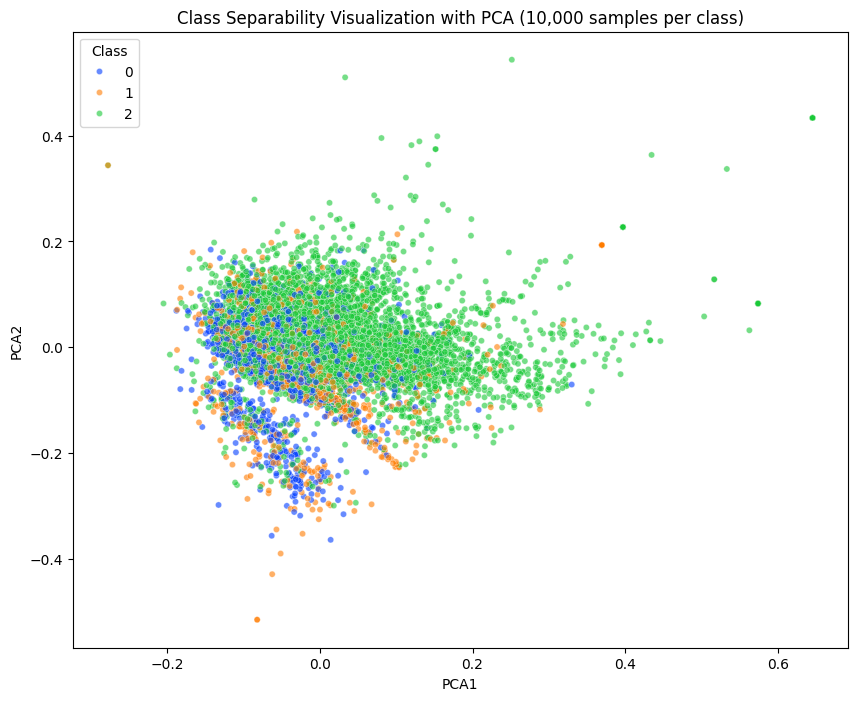

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

# Define your column names
text_col = 'Text_Abbr_Expanded'
class_col = 'Sentiment_Label'

# Sample the data if needed
df_sampled = df.sample(n=10000, random_state=42)

# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(df_sampled[text_col].values)

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Class': df_sampled[class_col].values
})

# Plot using seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Class', palette='bright', alpha=0.6, s=20)
plt.title('Class Separability Visualization with PCA (10,000 samples per class)')
plt.legend(title='Class')
plt.show()

Hence we can clearly see that there is a overlap in features with the class

<ipython-input-31-385dc4d1adf5>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment_3class', palette='pastel')


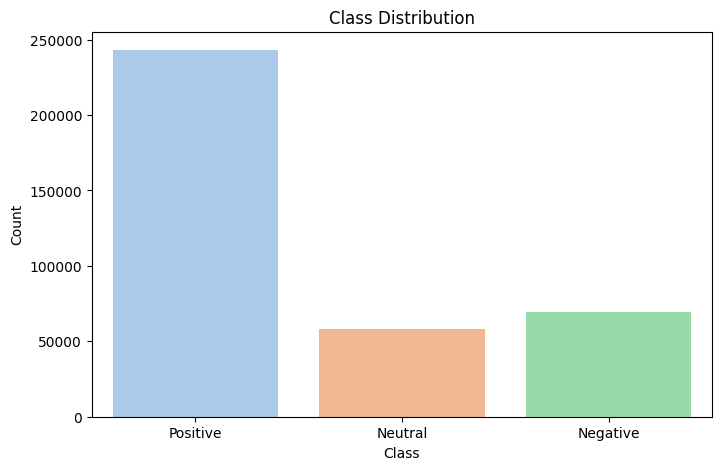

In [31]:
import seaborn as sns
# 1. Class Distribution (Count plot)
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sentiment_3class', palette='pastel')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

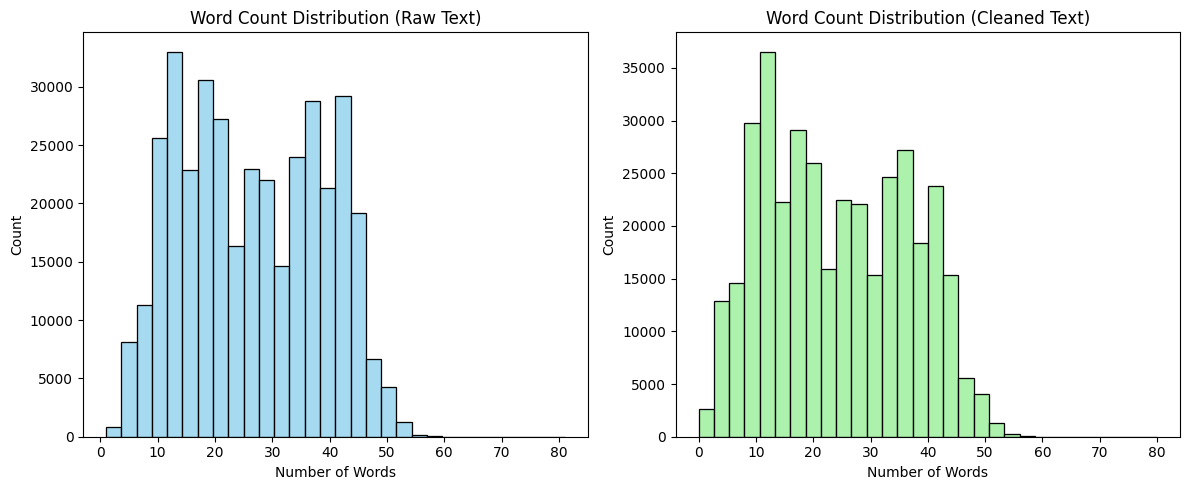

In [32]:
# 2. Word Count Distribution
df['word_count_raw'] = df['Tweet'].apply(lambda x: len(str(x).split()))
df['word_count_clean'] = df['Clean_Tweet_No_Emoji'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(df['word_count_raw'], bins=30, color='skyblue')
plt.title('Word Count Distribution (Raw Text)')
plt.xlabel('Number of Words')

plt.subplot(1, 2, 2)
sns.histplot(df['word_count_clean'], bins=30, color='lightgreen')
plt.title('Word Count Distribution (Cleaned Text)')
plt.xlabel('Number of Words')

plt.tight_layout()
plt.show()

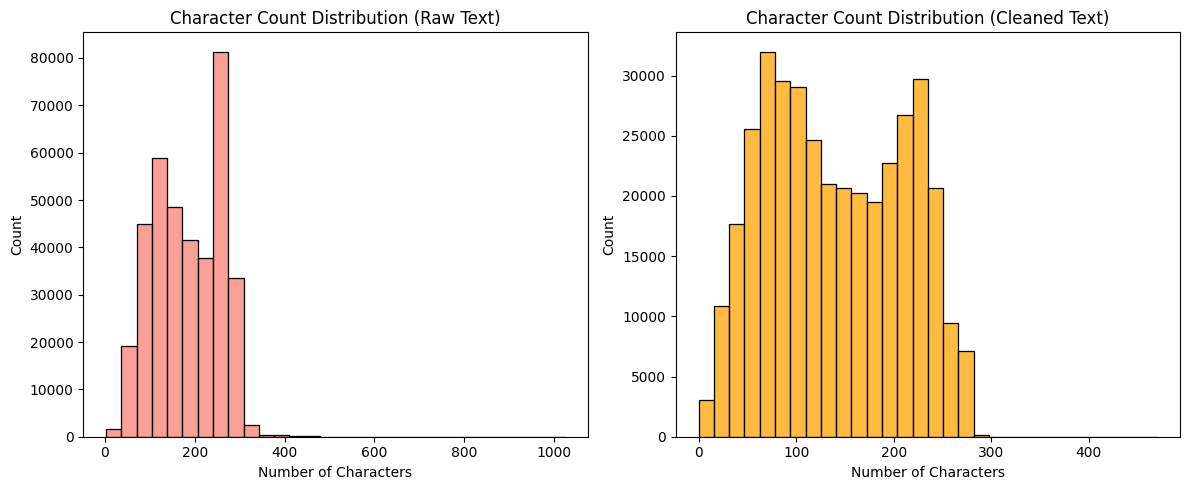

In [33]:
# 3. Character Count Distribution
df['char_count_raw'] = df['Tweet'].apply(lambda x: len(str(x)))
df['char_count_clean'] = df['Clean_Tweet_No_Emoji'].apply(lambda x: len(str(x)))

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
sns.histplot(df['char_count_raw'], bins=30, color='salmon')
plt.title('Character Count Distribution (Raw Text)')
plt.xlabel('Number of Characters')

plt.subplot(1, 2, 2)
sns.histplot(df['char_count_clean'], bins=30, color='orange')
plt.title('Character Count Distribution (Cleaned Text)')
plt.xlabel('Number of Characters')

plt.tight_layout()
plt.show()

In [34]:
# Check for missing values count
missing_values = df.isnull().sum()
print(missing_values)

# Optionally, print columns with missing values
missing_columns = missing_values[missing_values > 0]
print("Columns with missing values:", missing_columns)

Tweet                        1
Sentiment                    0
Clean_Tweet                  0
Sentiment_3class             0
Sentiment_Label              0
Clean_Tweet_No_Emoji         0
Clean_Tweet_Slang_Handled    0
Text_Abbr_Handled            0
abbreviations_found          0
Text_Abbr_Expanded           0
num_hashtags                 0
num_mentions                 0
num_urls                     0
num_exclamations             0
num_questions                0
num_uppercase_words          0
avg_word_len                 0
has_positive_word            0
has_negative_word            0
char_count                   0
word_count                   0
unique_word_count            0
word_density                 0
word_count_raw               0
word_count_clean             0
char_count_raw               0
char_count_clean             0
dtype: int64
Columns with missing values: Tweet    1
dtype: int64


In [35]:
df = df.dropna(subset=['Tweet'])

In [36]:
# 4. Missing Values Check
# Check for missing values count
missing_values = df.isnull().sum()
print(missing_values)

# Optionally, print columns with missing values
missing_columns = missing_values[missing_values > 0]
print("Columns with missing values:", missing_columns)

Tweet                        0
Sentiment                    0
Clean_Tweet                  0
Sentiment_3class             0
Sentiment_Label              0
Clean_Tweet_No_Emoji         0
Clean_Tweet_Slang_Handled    0
Text_Abbr_Handled            0
abbreviations_found          0
Text_Abbr_Expanded           0
num_hashtags                 0
num_mentions                 0
num_urls                     0
num_exclamations             0
num_questions                0
num_uppercase_words          0
avg_word_len                 0
has_positive_word            0
has_negative_word            0
char_count                   0
word_count                   0
unique_word_count            0
word_density                 0
word_count_raw               0
word_count_clean             0
char_count_raw               0
char_count_clean             0
dtype: int64
Columns with missing values: Series([], dtype: int64)


In [37]:
# 5. Emoji Removal Effect
sample_rows = df.sample(5, random_state=42)
for i, row in sample_rows.iterrows():
    print(f"Original Text:\n{row['Tweet']}\n")
    print(f"Cleaned without Emoji:\n{row['Clean_Tweet_No_Emoji']}\n")
    print("-" * 50)

Original Text:
Will the #police join or fight this #FreedomConvoy #Rotterdam #WalkOn #BeLikeWater my friend https://t.co/pLOEAqvTWf

Cleaned without Emoji:
will the  join or fight this     my friend

--------------------------------------------------
Original Text:
As if the whole world hasn't watch the freedom convoy unfold...

Hypocrisy at its finest.
#TrudeauMustGo #Democracy #cndpoli

Cleaned without Emoji:
as if the whole world hasnt watch the freedom convoy unfold

hypocrisy at its finest

--------------------------------------------------
Original Text:
@NoH2ONoBling @FourWinns298 I think your still giving him to much credit, lol how he treats nurseâs.  The Conservatives mandate for YEARS is to underfund education and healthcare.  You can control and manipulate the uneducated (Freedom Convoy) and the s

Cleaned without Emoji:
i think your still giving him to much credit lol how he treats nurseâs  the conservatives mandate for years is to underfund education and healthcare  you

In [38]:
# 6. Slang & Abbreviation Replacement Effect
if 'Clean_Tweet_Slang_Handled' in df.columns and 'Text_Abbr_Handled' in df.columns:
    sample_rows = df.sample(5, random_state=101)
    for i, row in sample_rows.iterrows():
        print(f"Before Slang/Abbr Handling:\n{row['Clean_Tweet_No_Emoji']}\n")
        print(f"After Slang/Abbr Handling:\n{row['Text_Abbr_Handled']}\n")
        print("=" * 50)

Before Slang/Abbr Handling:
remember when  was one of the largest ontario donors to the freedom convoy

After Slang/Abbr Handling:
remember when was one of the largest ontario donors to the freedom convoy

Before Slang/Abbr Handling:
the vaccination mandate was imposed on the truckers by the federal gobernment which is why the freedom convoy headed to ottawa  or did you totally miss what happened there

also vaccination mandates for domestc flights

After Slang/Abbr Handling:
the vaccination mandate was imposed on the truckers by the federal gobernment which is why the freedom convoy headed to ottawa or did you totally miss what happened there also vaccination mandates for domestc flights

Before Slang/Abbr Handling:
justin trudeau and this is only once only please and let them go and thier patriots and peaceful protest against faical mask mandates and its canadian freedom convoy rally and my own 1988 olympic team what i led and were haveing our own

After Slang/Abbr Handling:
justin t

<ipython-input-39-987c1a27cdd5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment_3class', y='char_count_clean', data=df, palette='pastel')


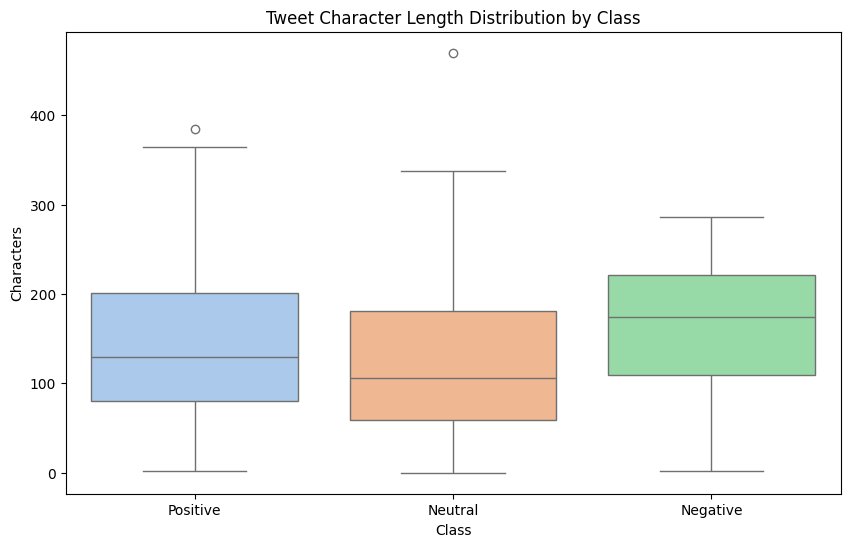

In [39]:
# 7. Distribution of tweet lengths by class
plt.figure(figsize=(10,6))
sns.boxplot(x='Sentiment_3class', y='char_count_clean', data=df, palette='pastel')
plt.title('Tweet Character Length Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Characters')
plt.show()

<ipython-input-40-736764881e3e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment_3class', y='word_count_clean', data=df, palette='pastel')


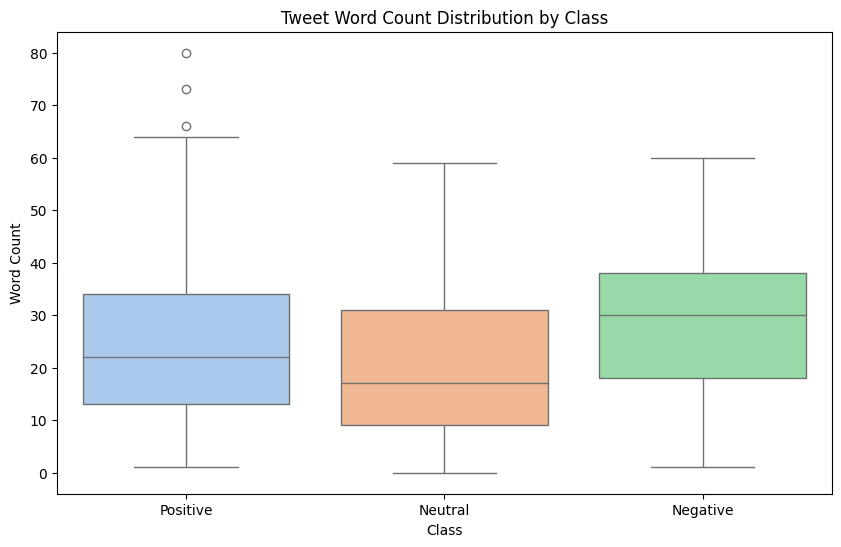

In [40]:
# 8. Distribution of word counts by class
plt.figure(figsize=(10,6))
sns.boxplot(x='Sentiment_3class', y='word_count_clean', data=df, palette='pastel')
plt.title('Tweet Word Count Distribution by Class')
plt.xlabel('Class')
plt.ylabel('Word Count')
plt.show()

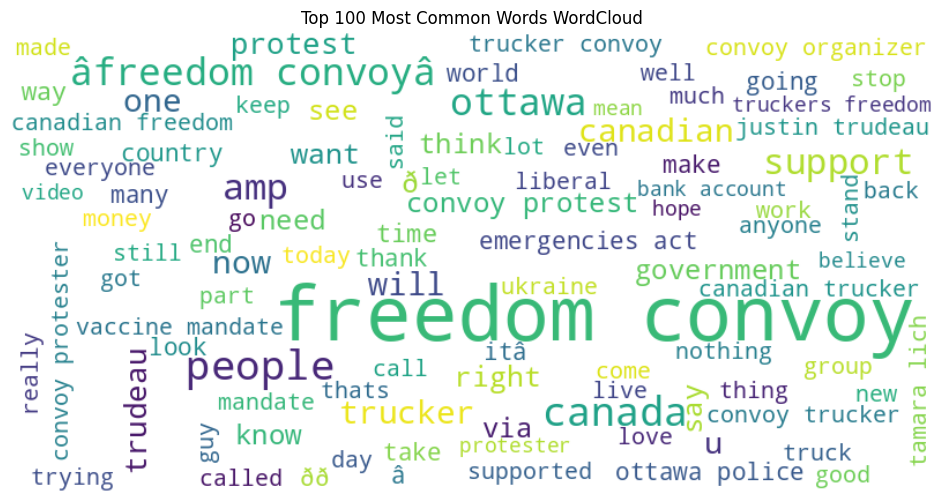

In [41]:
# 10. Top 20 most common words overall
from collections import Counter
from wordcloud import WordCloud

# Combine all cleaned tweets text into one string
all_text = ' '.join(df['Clean_Tweet_No_Emoji'].dropna().values)

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Common Words WordCloud')
plt.show()

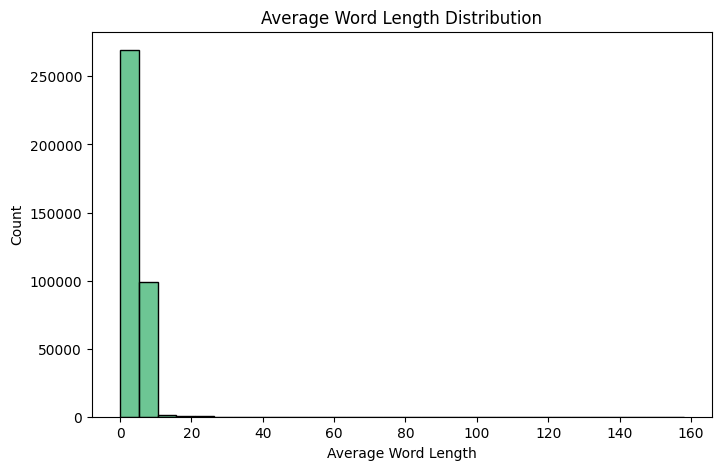

In [42]:
# 11. Average word length distribution
df['avg_word_len'] = df['Clean_Tweet_No_Emoji'].apply(lambda x:
                                                     (sum(len(w) for w in x.split()) / len(x.split())) if len(x.split())>0 else 0)
plt.figure(figsize=(8,5))
sns.histplot(df['avg_word_len'], bins=30, color='mediumseagreen')
plt.title('Average Word Length Distribution')
plt.xlabel('Average Word Length')
plt.ylabel('Count')
plt.show()

## Class Balance

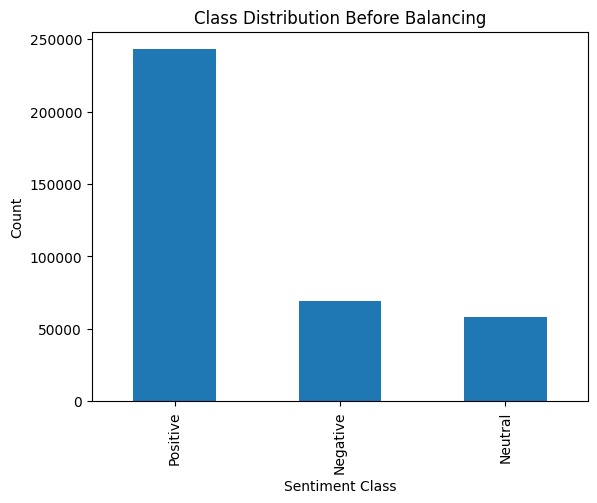

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Sentiment_3class'].value_counts().plot(kind='bar', title='Class Distribution Before Balancing')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

In [44]:
# Minimum number of samples in any class
min_count = df['Sentiment_3class'].value_counts().min()

# Sample equally from each class
df_balanced = df.groupby('Sentiment_3class').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)

<ipython-input-44-71b8bb861e30>:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('Sentiment_3class').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)


In [45]:
import numpy as np
import pandas as pd

print("Before balancing:\n", df['Sentiment_3class'].value_counts())

# For undersampling
print("After undersampling:\n", df_balanced['Sentiment_3class'].value_counts())

Before balancing:
 Sentiment_3class
Positive    243048
Negative     69310
Neutral      57900
Name: count, dtype: int64
After undersampling:
 Sentiment_3class
Negative    57900
Neutral     57900
Positive    57900
Name: count, dtype: int64


In [46]:
df.head()

,Tweet,Sentiment,Clean_Tweet,Sentiment_3class,Sentiment_Label,Clean_Tweet_No_Emoji,Clean_Tweet_Slang_Handled,Text_Abbr_Handled,abbreviations_found,Text_Abbr_Expanded,...,has_positive_word,has_negative_word,char_count,word_count,unique_word_count,word_density,word_count_raw,word_count_clean,char_count_raw,char_count_clean
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos,happy anniversarythe day the freedumb died in ...,Positive,2,happy anniversarythe day the freedumb died in ...,happy anniversarythe day the freedumb died in ...,happy anniversarythe day the freedumb died in ...,[],happy anniversarythe day the freedumb died in ...,...,1,0,82,14,13,5.466667,22,14,213,82
8,Freedom Convoy as InkBlot Test https://t.co/au...,Strong_Pos,freedom convoy as inkblot test,Positive,2,freedom convoy as inkblot test,freedom convoy as inkblot test,freedom convoy as inkblot test,[],freedom convoy as inkblot test,...,0,0,30,5,5,5.000000,6,5,54,30
13,@mark_slapinski Well itâs pretty easy to see...,Strong_Pos,well itâs pretty easy to see what their agenda...,Positive,2,well itâs pretty easy to see what their agenda...,well itâs pretty easy to see what their agenda...,well itâs pretty easy to see what their agenda...,[],well itâs pretty easy to see what their agenda...,...,0,0,158,31,29,4.937500,32,31,176,158
23,@JustinTrudeau You Belong In Jail.\n#VaccineMa...,Neutral,you belong in jail,Neutral,1,you belong in jail,you belong in jail,you belong in jail,[],you belong in jail,...,0,0,18,4,4,3.600000,10,4,134,18
25,#FreeDumbConvoy #FreedomConvoy #Freedumbers #f...,Neutral,,Neutral,1,,,,[],,...,0,0,0,0,0,0.000000,5,0,62,0


In [47]:
df['Text_Abbr_Expanded'].head()

,Text_Abbr_Expanded
0,happy anniversarythe day the freedumb died in ...
8,freedom convoy as inkblot test
13,well itâs pretty easy to see what their agenda...
23,you belong in jail
25,


In [48]:
df['Sentiment_Label'].head()

,Sentiment_Label
0,2
8,2
13,2
23,1
25,1


## Train Test Split

In [49]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# Input text and labels
X_text = df_balanced['Text_Abbr_Expanded']
y = df_balanced['Sentiment_Label']

# Tokenize text
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_text)
X_seq = tokenizer.texts_to_sequences(X_text)

# Pad sequences
maxlen = 100
X_padded = pad_sequences(X_seq, maxlen=maxlen, padding='post')

# Convert labels to categorical (for softmax classification)
y_cat = to_categorical(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_cat, test_size=0.2, stratify=y, random_state=42
)

In [50]:
import pandas as pd

# Convert to DataFrames for easier saving to CSV
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

# Reverse the one-hot encoding of labels to get the original labels back
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Create DataFrames for labels
y_train_df = pd.DataFrame(y_train_labels, columns=['Sentiment_Label'])
y_test_df = pd.DataFrame(y_test_labels, columns=['Sentiment_Label'])

# Save train and test data to CSV
X_train_df.to_csv('X_train.csv', index=False)
X_test_df.to_csv('X_test.csv', index=False)
y_train_df.to_csv('y_train.csv', index=False)
y_test_df.to_csv('y_test.csv', index=False)

print("Train and Test data saved successfully!")

Train and Test data saved successfully!


## LLM Prompts
- give code for mounting gdrive to extract
- give code for splitting dataset and saving
- how to show words in wordcloud
- how to do pca for class separatability
- how to replace slang and hangle regex